# EDA On Lending Loan Dataset

### Dataset Info
- **Dataset**  : LendingClub Loan Data (2007–2018)
- **Source**  : LendingClub — the largest US peer-to-peer lending platform
- **Records**  : ~2 million loan applications
- **Columns used**  : 23 (reduced from 151)
- **Time Period**  : 2007 to 2018     
- **What this dataset contains**  :
    Every row is one loan issued by LendingClub. It captures borrower profile, loan characteristics, and final loan outcome — making it ideal for credit risk analysis
- **Why this dataset**:
    Real-world, large-scale, messy financial data with genuine business relevance — used widely in industry for default prediction, risk modeling, and lending strategy.

### Import Libraries
* Numpy for Numerical Series and array exporation
* Pandas for Analysis and Data Manipulation
* Matplotlib for Visual demonstrate and Data Points identifing
* Seaborn for advance Visuals and Multivariat Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#### The Data

In [2]:
fin_full = pd.read_csv('../Data/Lending_loan_cleaned.csv')

In [3]:
fin_full.shape

(2260639, 23)

In [4]:
fin_full.size

51994697

In [5]:
fin_full['loan_amnt'].skew()

np.float64(0.7777793877122572)

In [6]:
fin_full.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
0,3600.0,36,13.99,123.03,C,C4,10+ years,MORTGAGE,55000.0,Not Verified,...,PA,5.91,2003-08-01,675.0,679.0,7.0,0.0,2765.0,29.7,13.0
1,24700.0,36,11.99,820.28,C,C1,10+ years,MORTGAGE,65000.0,Not Verified,...,SD,16.06,1999-12-01,715.0,719.0,22.0,0.0,21470.0,19.2,38.0
2,20000.0,60,10.78,432.66,B,B4,10+ years,MORTGAGE,63000.0,Not Verified,...,IL,10.78,2000-08-01,695.0,699.0,6.0,0.0,7869.0,56.2,18.0
3,35000.0,60,14.85,829.90,C,C5,10+ years,MORTGAGE,110000.0,Source Verified,...,NJ,17.06,2008-09-01,785.0,789.0,13.0,0.0,7802.0,11.6,17.0
4,10400.0,60,22.45,289.91,F,F1,3 years,MORTGAGE,104433.0,Source Verified,...,PA,25.37,1998-06-01,695.0,699.0,12.0,0.0,21929.0,64.5,35.0


 #### Sample Data
 - **Details** - For Fast and Helthy analysis on LendingClub Loan Dataset i am here using a sample of dataset instead of full 2M rows data

In [7]:
fin = fin_full.sample(frac=0.05, random_state=42)

In [8]:
fin.shape

(113032, 23)

In [9]:
fin['loan_amnt'].skew()

np.float64(0.7753287546331561)

#### Column Types

- **Numeric** -  loan_amnt, term, int_rate, installment, annual_inc, dti, fico_range_low, fico_range_high, open_acc, pub_rec, revol_util, total_acc
- **Categorical** - grade, home_owenership, annual_inc, verification_status, loan_status, purpose, addr_state, 
- **Datetime** - issue_d, earliest_cr_line, 
- **Mix Type** - sub_grade, emp_length, 

#### Tier 1
- Highly effective columns

    - `loan_status`
    - `int_rate`
    - `grade/sub_grade`
    - `dti`  
    - `fico_range_low/high` 
    - `annual_inc`
    - `loan_amnt`

### Univariate Analysis on Tier 1 Numerical columns

#### loan_amnt

**Conclusions**

- loan_amnt is moderately right-skewed (skew = 0.78). Median loan is ~$12,900, meaning most borrowers take smaller loans. The distribution peaks around $10K-$15K range. 
- High-value loans above $37K (~1,900 records or 1.7% of sample) represent the outlier tail — these are worth monitoring separately in risk analysis as larger exposures.

In [10]:
fin['loan_amnt'].describe()

count    113032.00000
mean      15078.71355
std        9195.09158
min         500.00000
25%        8000.00000
50%       13000.00000
75%       20000.00000
max       40000.00000
Name: loan_amnt, dtype: float64

<Axes: ylabel='Frequency'>

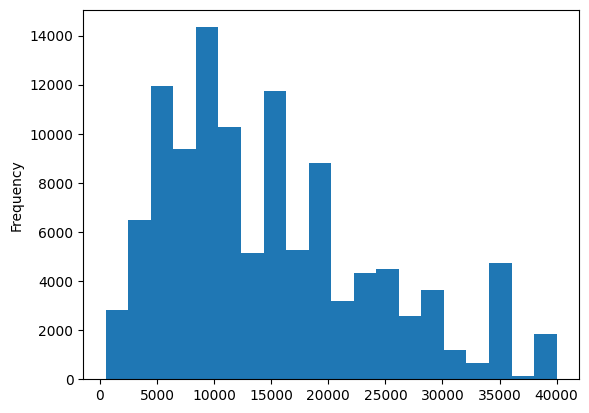

In [11]:
fin['loan_amnt'].plot(kind='hist', bins= 20)

<Axes: ylabel='Density'>

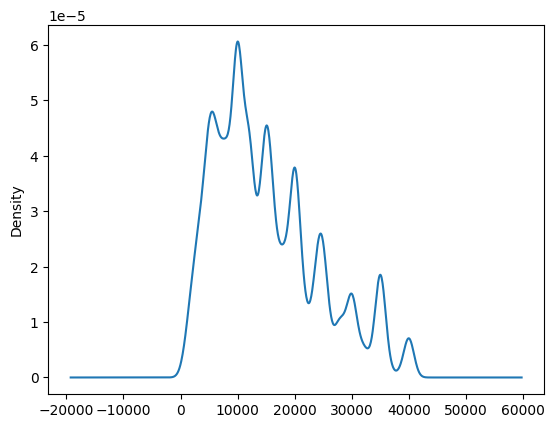

In [12]:
fin['loan_amnt'].plot(kind= 'kde')

<Axes: >

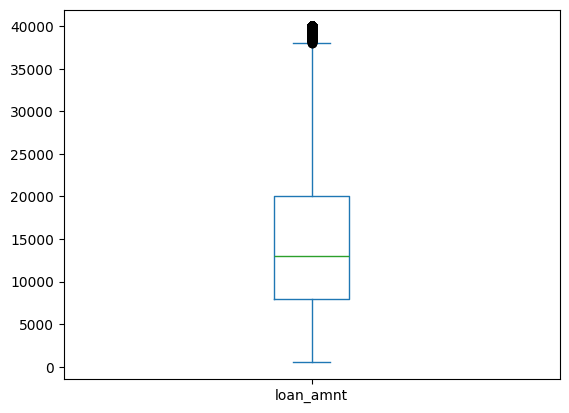

In [13]:
fin['loan_amnt'].plot(kind= 'box')

In [14]:
fin[fin['loan_amnt']>37000]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
1538170,40000.0,60,14.52,941.55,C,C3,10+ years,MORTGAGE,85000.0,Verified,...,PA,25.98,1995-11-01,705.0,709.0,17.0,0.0,18407.0,32.6,24.0
925529,40000.0,36,19.03,1466.85,D,D3,1 year,MORTGAGE,141000.0,Verified,...,TX,12.44,2004-02-01,680.0,684.0,14.0,0.0,22886.0,66.1,24.0
1577932,37800.0,36,9.92,1218.29,B,B2,10+ years,MORTGAGE,160000.0,Verified,...,FL,28.90,1999-03-01,705.0,709.0,26.0,0.0,33094.0,25.0,75.0
874813,40000.0,60,12.13,892.41,B,B5,10+ years,MORTGAGE,105000.0,Source Verified,...,NC,35.25,1999-10-01,695.0,699.0,18.0,0.0,87904.0,69.1,34.0
560241,40000.0,60,13.59,922.25,C,C2,4 years,MORTGAGE,102000.0,Source Verified,...,GA,13.65,1998-12-01,700.0,704.0,18.0,0.0,16356.0,78.2,22.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
585914,40000.0,60,14.08,932.39,C,C3,8 years,MORTGAGE,130000.0,Verified,...,MN,10.49,1998-06-01,710.0,714.0,8.0,0.0,33339.0,68.7,17.0
1557769,40000.0,36,11.98,1328.20,B,B5,9 years,MORTGAGE,148500.0,Verified,...,SC,27.01,1995-05-01,730.0,734.0,30.0,0.0,9249.0,10.7,45.0
767003,39625.0,36,12.73,1329.98,B,B5,6 years,OWN,215000.0,Source Verified,...,NJ,12.78,1997-02-01,690.0,694.0,11.0,0.0,38986.0,65.4,35.0
712578,40000.0,36,11.47,1318.47,B,B5,5 years,OWN,182000.0,Verified,...,AZ,35.05,1993-03-01,740.0,744.0,23.0,0.0,81120.0,55.2,41.0


#### int_rate

 **Conclusions**

- int_rate col contain 0.76 skew here so it is not normal distribution 
- this col have right side skewed data
- int_col contains outliers


In [15]:
fin['int_rate'].describe()

count    113032.000000
mean         13.075182
std           4.808103
min           5.310000
25%           9.490000
50%          12.620000
75%          15.990000
max          30.990000
Name: int_rate, dtype: float64

In [16]:
fin['int_rate'].skew()

np.float64(0.7629866023250008)

<Axes: ylabel='Frequency'>

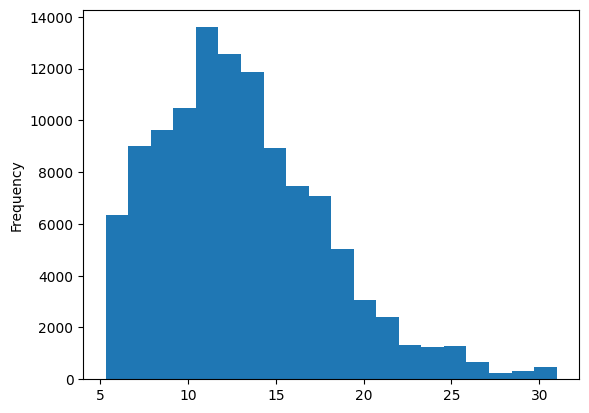

In [17]:
fin['int_rate'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

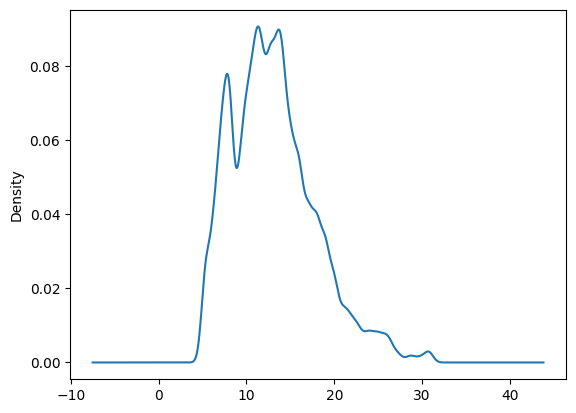

In [18]:
fin['int_rate'].plot(kind='kde')

<Axes: >

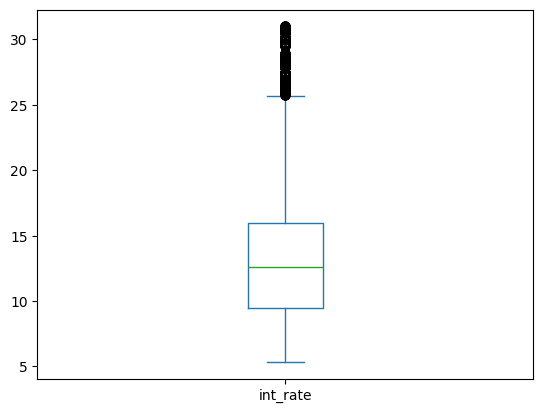

In [19]:
fin['int_rate'].plot(kind='box')

In [20]:
fin[fin['int_rate']> 27]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
551002,18950.0,60,30.65,620.69,F,F4,< 1 year,MORTGAGE,22880.0,Source Verified,...,NE,8.48,2005-04-01,665.0,669.0,5.0,0.0,4041.0,89.8,8.0
1979743,19200.0,60,27.79,595.38,F,F5,4 years,RENT,52000.0,Not Verified,...,NY,34.73,2006-09-01,675.0,679.0,12.0,1.0,22258.0,70.9,24.0
2167883,13200.0,60,30.74,433.09,F,F5,10+ years,OWN,80000.0,Source Verified,...,IN,9.08,2006-06-01,695.0,699.0,21.0,0.0,2922.0,7.0,33.0
613150,30000.0,60,30.17,973.74,F,F3,< 1 year,MORTGAGE,60000.0,Verified,...,IL,3.88,2012-11-01,725.0,729.0,6.0,0.0,5771.0,31.4,7.0
2147792,32000.0,60,29.69,1029.23,F,F2,9 years,MORTGAGE,100000.0,Verified,...,CA,32.49,1991-09-01,670.0,674.0,21.0,1.0,9691.0,26.4,71.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2249570,12000.0,60,27.49,369.95,F,F4,10+ years,MORTGAGE,50000.0,Verified,...,NY,17.83,2001-10-01,705.0,709.0,20.0,0.0,15998.0,36.9,38.0
195874,15000.0,60,27.31,460.82,G,G2,7 years,MORTGAGE,42000.0,Verified,...,NH,25.06,2003-09-01,700.0,704.0,13.0,0.0,8144.0,38.2,19.0
2203247,35000.0,60,28.69,1104.37,F,F1,2 years,MORTGAGE,150000.0,Source Verified,...,WI,12.62,2006-01-01,670.0,674.0,13.0,0.0,28016.0,84.0,19.0
989660,35000.0,60,28.67,1103.95,G,G4,3 years,MORTGAGE,74000.0,Not Verified,...,VA,39.99,1999-10-01,705.0,709.0,18.0,0.0,27105.0,81.4,58.0


#### dti

**Conclusions**

- 

In [21]:
fin['dti'].describe()

count    113032.000000
mean         18.806808
std          14.661394
min           0.000000
25%          11.870000
50%          17.820000
75%          24.470000
max         999.000000
Name: dti, dtype: float64

In [22]:
fin['dti'].skew()

np.float64(29.68526835610812)

<Axes: ylabel='Frequency'>

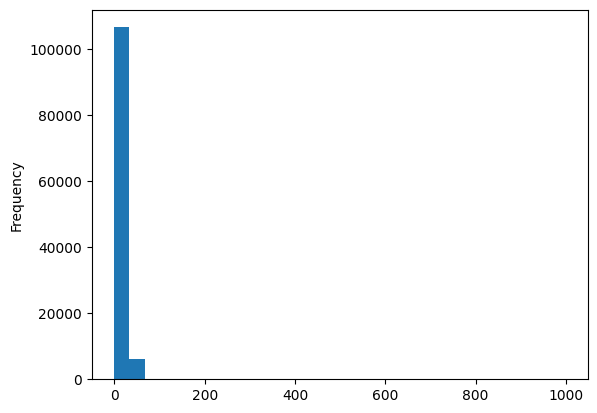

In [23]:
fin['dti'].plot(kind='hist',bins=30)

<Axes: ylabel='Density'>

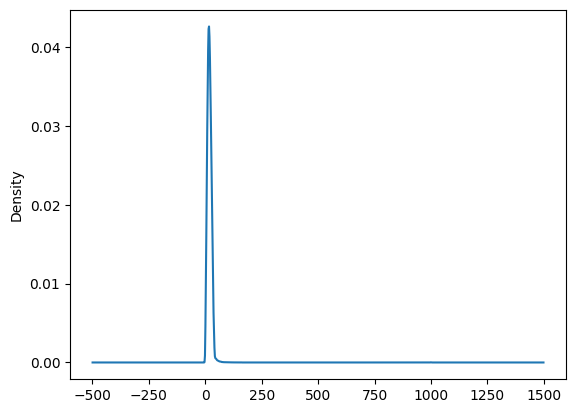

In [24]:
fin['dti'].plot(kind='kde')

<Axes: >

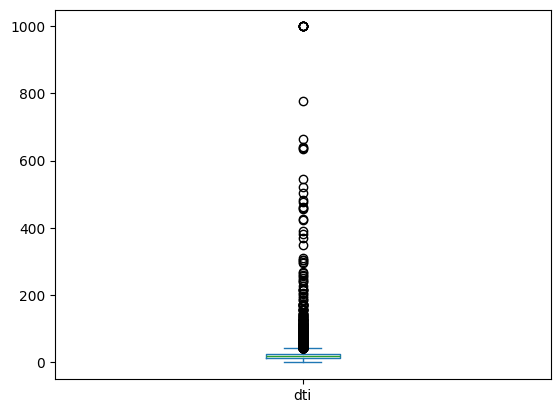

In [25]:
fin['dti'].plot(kind='box')

#### fico_range_low

**Conclusions**

- 

In [29]:
fin['fico_range_low'].describe()

count    113032.000000
mean        698.642464
std          33.116370
min         640.000000
25%         675.000000
50%         690.000000
75%         715.000000
max         845.000000
Name: fico_range_low, dtype: float64

In [30]:
fin['fico_range_low'].skew()

np.float64(1.2047005075054227)

<Axes: ylabel='Frequency'>

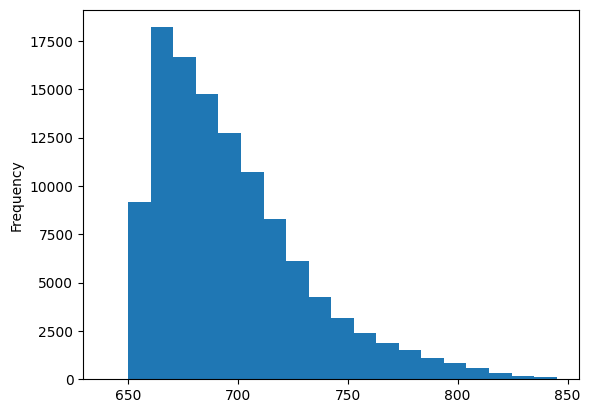

In [32]:
fin['fico_range_low'].plot(kind='hist', bins=20)

<Axes: ylabel='Density'>

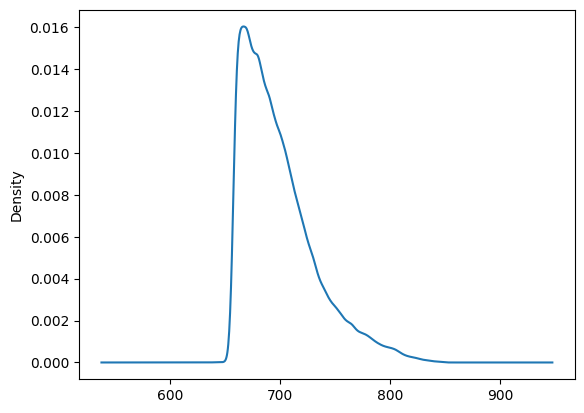

In [33]:
fin['fico_range_low'].plot(kind='kde')

<Axes: >

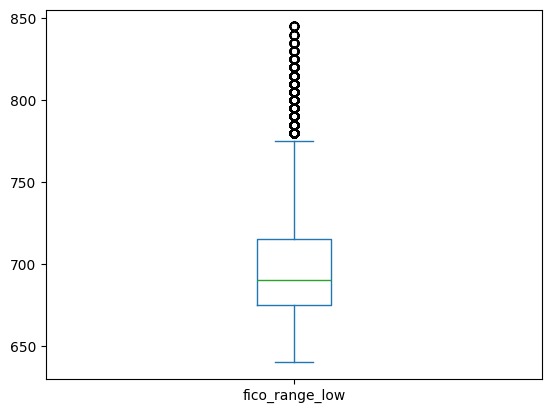

In [34]:
fin['fico_range_low'].plot(kind='box')

In [36]:
fin[fin['fico_range_low'] > 775]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
1423761,3000.0,36,8.81,95.14,A,A5,8 years,OWN,61000.0,Not Verified,...,TX,32.23,2003-07-01,780.0,784.0,6.0,0.0,14141.0,33.4,45.0
2121743,19000.0,36,5.32,572.19,A,A1,5 years,RENT,119000.0,Verified,...,FL,11.02,2010-09-01,800.0,804.0,15.0,0.0,0.0,0.0,23.0
830700,35000.0,36,6.67,1075.43,A,A2,3 years,RENT,145000.0,Source Verified,...,CA,22.23,2002-02-01,795.0,799.0,18.0,0.0,26119.0,12.1,35.0
1652766,1000.0,36,8.59,31.62,A,A4,1 year,MORTGAGE,120000.0,Not Verified,...,WI,12.05,1992-12-01,805.0,809.0,4.0,0.0,269726.0,4.3,13.0
1019629,20000.0,36,5.32,602.30,A,A1,10+ years,MORTGAGE,73000.0,Not Verified,...,NH,15.57,2001-02-01,815.0,819.0,14.0,0.0,9660.0,13.6,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111896,35000.0,60,13.99,814.21,C,C4,10+ years,MORTGAGE,95000.0,Source Verified,...,OK,24.23,1985-08-01,780.0,784.0,28.0,0.0,5470.0,11.8,33.0
1369766,20000.0,60,12.98,454.86,B,B5,Unknown,MORTGAGE,72000.0,Verified,...,AZ,24.93,1987-12-01,795.0,799.0,17.0,0.0,5895.0,12.0,38.0
1074303,10000.0,36,6.49,306.45,A,A2,< 1 year,MORTGAGE,40000.0,Not Verified,...,CO,19.94,1996-11-01,790.0,794.0,13.0,0.0,9528.0,9.2,22.0
1027363,12500.0,36,5.32,376.44,A,A1,< 1 year,MORTGAGE,80000.0,Not Verified,...,MA,18.71,2003-11-01,805.0,809.0,9.0,0.0,1304.0,5.3,12.0


#### fico_rate_high

**Conclusion**

- 

In [38]:
fin['fico_range_high'].describe()

count    113032.000000
mean        702.642703
std          33.117430
min         644.000000
25%         679.000000
50%         694.000000
75%         719.000000
max         850.000000
Name: fico_range_high, dtype: float64

In [ ]:
fin['fico_range_high'].skew()

np.float64(1.2049887922353522)

<Axes: ylabel='Frequency'>

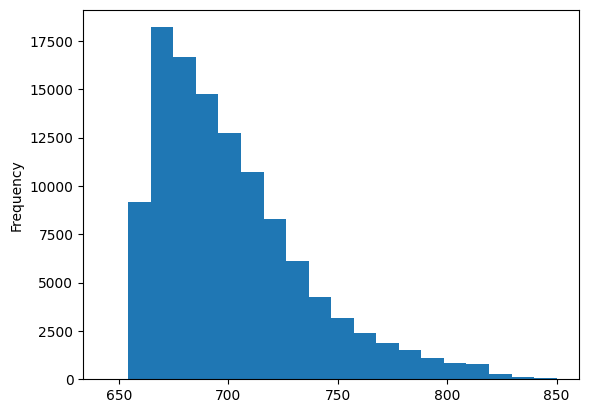

In [41]:
fin['fico_range_high'].plot(kind='hist',bins=20)

<Axes: ylabel='Density'>

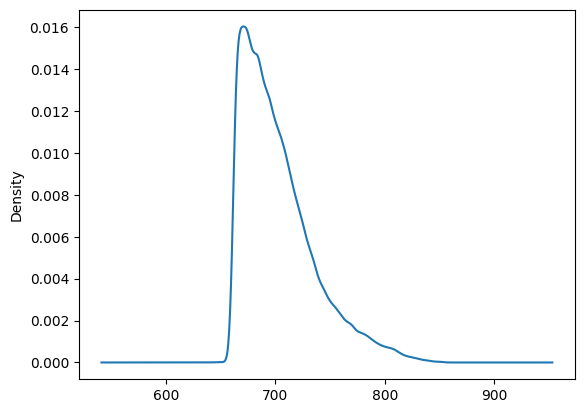

In [42]:
fin['fico_range_high'].plot(kind='kde')

<Axes: >

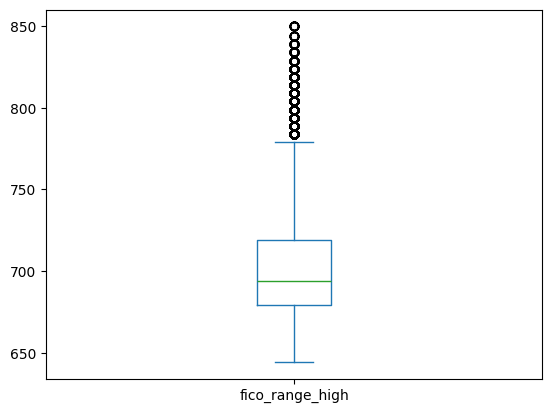

In [43]:
fin['fico_range_high'].plot(kind='box')

In [44]:
fin[fin['fico_range_high'] > 775]

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,addr_state,dti,earliest_cr_line,fico_range_low,fico_range_high,open_acc,pub_rec,revol_bal,revol_util,total_acc
1423761,3000.0,36,8.81,95.14,A,A5,8 years,OWN,61000.0,Not Verified,...,TX,32.23,2003-07-01,780.0,784.0,6.0,0.0,14141.0,33.4,45.0
2121743,19000.0,36,5.32,572.19,A,A1,5 years,RENT,119000.0,Verified,...,FL,11.02,2010-09-01,800.0,804.0,15.0,0.0,0.0,0.0,23.0
830700,35000.0,36,6.67,1075.43,A,A2,3 years,RENT,145000.0,Source Verified,...,CA,22.23,2002-02-01,795.0,799.0,18.0,0.0,26119.0,12.1,35.0
1652766,1000.0,36,8.59,31.62,A,A4,1 year,MORTGAGE,120000.0,Not Verified,...,WI,12.05,1992-12-01,805.0,809.0,4.0,0.0,269726.0,4.3,13.0
1019629,20000.0,36,5.32,602.30,A,A1,10+ years,MORTGAGE,73000.0,Not Verified,...,NH,15.57,2001-02-01,815.0,819.0,14.0,0.0,9660.0,13.6,28.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1369766,20000.0,60,12.98,454.86,B,B5,Unknown,MORTGAGE,72000.0,Verified,...,AZ,24.93,1987-12-01,795.0,799.0,17.0,0.0,5895.0,12.0,38.0
1074303,10000.0,36,6.49,306.45,A,A2,< 1 year,MORTGAGE,40000.0,Not Verified,...,CO,19.94,1996-11-01,790.0,794.0,13.0,0.0,9528.0,9.2,22.0
1027363,12500.0,36,5.32,376.44,A,A1,< 1 year,MORTGAGE,80000.0,Not Verified,...,MA,18.71,2003-11-01,805.0,809.0,9.0,0.0,1304.0,5.3,12.0
274112,20000.0,60,7.89,404.48,A,A5,10+ years,MORTGAGE,103000.0,Source Verified,...,OH,12.83,1999-03-01,780.0,784.0,12.0,0.0,18849.0,16.1,24.0
